In [ ]:
import random
import time
import numpy as np
import pandas as pd

In [ ]:
device_types = {
    "Temperature Sensor": "Low",
    "Humidity Sensor": "Low",
    "Motion Sensor": "Medium",
    "Smart Light": "Medium",
    "Smoke Detector": "High",
    "Door Lock": "High"
}

In [ ]:
def generate_devices(num_devices):
    devices = []

    for i in range(num_devices):
        device_name = random.choice(list(device_types.keys()))
        priority = device_types[device_name]

        device = {
            "device_id": f"D{i+1}",
            "device_type": device_name,
            "priority": priority
        }

        devices.append(device)

    return devices

In [ ]:
def generate_sensor_value(device_type):

    if device_type == "Temperature Sensor":
        return round(random.uniform(20, 35), 2)

    elif device_type == "Humidity Sensor":
        return round(random.uniform(40, 80), 2)

    elif device_type == "Motion Sensor":
        return random.choice([0, 1])

    elif device_type == "Smart Light":
        return random.choice(["ON", "OFF"])

    elif device_type == "Smoke Detector":
        return random.choice([0, 1])

    elif device_type == "Door Lock":
        return random.choice(["LOCKED", "UNLOCKED"])

SECTION 5 — MULTI-CYCLE SENSOR TRAFFIC GENERATION

In [ ]:
def generate_sensor_packets(devices, cycles=10):

    packets = []

    for cycle in range(cycles):

        timestamp = time.time()

        for device in devices:

            packet = {
                "device_id": device["device_id"],
                "device_type": device["device_type"],
                "priority": device["priority"],
                "timestamp": timestamp,
                "sensor_value": generate_sensor_value(
                    device["device_type"]
                )
            }

            packets.append(packet)

    return packets

SECTION 6: RUN

In [ ]:
num_devices = 50

devices = generate_devices(num_devices)

packets = generate_sensor_packets(
    devices,
    cycles=20
)

df = pd.DataFrame(packets)

print(df.head(10))

  device_id         device_type priority     timestamp sensor_value
0        D1           Door Lock     High  1.779785e+09     UNLOCKED
1        D2      Smoke Detector     High  1.779785e+09            0
2        D3      Smoke Detector     High  1.779785e+09            1
3        D4      Smoke Detector     High  1.779785e+09            0
4        D5     Humidity Sensor      Low  1.779785e+09        49.52
5        D6     Humidity Sensor      Low  1.779785e+09         73.1
6        D7       Motion Sensor   Medium  1.779785e+09            1
7        D8  Temperature Sensor      Low  1.779785e+09        22.85
8        D9           Door Lock     High  1.779785e+09       LOCKED
9       D10           Door Lock     High  1.779785e+09     UNLOCKED


SECTION 7 — CONVENTIONAL MIDDLEWARE PROCESSING

In [ ]:
def conventional_middleware(packets):

    processed_packets = []

    transmission_energy = 0
    reception_energy = 0
    processing_energy = 0

    total_latency = 0

    for packet in packets:

        # Receive packet
        reception_energy += 0.5

        # Process packet
        processing_energy += 1.0

        # Forward packet
        transmission_energy += 0.8

        # Simulated latency
        latency = random.uniform(1, 5)
        total_latency += latency

        processed_packets.append(packet)

    total_energy = (
        transmission_energy
        + reception_energy
        + processing_energy
    )

    throughput = len(processed_packets)


    results = {
    "Processed Packets": len(processed_packets),
    "Transmission Energy": round(transmission_energy, 2),
    "Reception Energy": round(reception_energy, 2),
    "Processing Energy": round(processing_energy, 2),
    "Total Energy": round(total_energy, 2),
    "Average Latency": round(
        total_latency / len(processed_packets), 2
    ),
    "Throughput": throughput
}

    return results

SECTION 8 — RUN CONVENTIONAL MIDDLEWARE

In [ ]:
conventional_results = conventional_middleware(packets)

print("\nConventional Middleware Results:\n")

for key, value in conventional_results.items():
    print(f"{key}: {value}")


Conventional Middleware Results:

Processed Packets: 1000
Transmission Energy: 800.0
Reception Energy: 500.0
Processing Energy: 1000.0
Total Energy: 2300.0
Average Latency: 3.05
Throughput: 1000


SECTION 9 — ADAPTIVE MIDDLEWARE IMPLEMENTATION

In [ ]:
def adaptive_middleware(packets, threshold=2):

    processed_packets = []

    transmission_energy = 0
    reception_energy = 0
    processing_energy = 0

    total_latency = 0

    previous_values = {}

    redundant_packets = 0

    for packet in packets:

        device_id = packet["device_id"]
        device_type = packet["device_type"]
        priority = packet["priority"]
        current_value = packet["sensor_value"]

        # Receive packet
        reception_energy += 0.4

        transmit = True

        # ---------------------------------
        # REDUNDANT DATA FILTERING
        # ---------------------------------

        if isinstance(current_value, (int, float)):

            if device_id in previous_values:

                previous_value = previous_values[device_id]

                if abs(current_value - previous_value) < threshold:
                    transmit = False
                    redundant_packets += 1

            previous_values[device_id] = current_value

        # ---------------------------------
        # PRIORITY-BASED PROCESSING
        # ---------------------------------

        if priority == "High":
            latency = random.uniform(0.5, 1.5)

        elif priority == "Medium":
            latency = random.uniform(1, 3)

        else:
            latency = random.uniform(2, 5)

        # ---------------------------------
        # PROCESS & TRANSMIT
        # ---------------------------------

        if transmit:

            processing_energy += 0.7
            transmission_energy += 0.5

            total_latency += latency

            processed_packets.append(packet)

    total_energy = (
        transmission_energy
        + reception_energy
        + processing_energy
    )

    throughput = len(processed_packets)

    communication_overhead = (
        redundant_packets / len(packets)
    ) * 100

    results = {
        "Processed Packets": len(processed_packets),
        "Redundant Packets Filtered": redundant_packets,
        "Transmission Energy": round(transmission_energy, 2),
        "Reception Energy": round(reception_energy, 2),
        "Processing Energy": round(processing_energy, 2),
        "Total Energy": round(total_energy, 2),
        "Average Latency": round(
            total_latency / len(processed_packets), 2
        ),
        "Throughput": throughput,
        "Communication Overhead Reduction (%)":
            round(communication_overhead, 2)
    }

    return results

SECTION 10 — RUN ADAPTIVE MIDDLEWARE

In [ ]:
adaptive_results = adaptive_middleware(packets)

print("\nAdaptive Middleware Results:\n")

for key, value in adaptive_results.items():
    print(f"{key}: {value}")


Adaptive Middleware Results:

Processed Packets: 575
Redundant Packets Filtered: 425
Transmission Energy: 287.5
Reception Energy: 400.0
Processing Energy: 402.5
Total Energy: 1090.0
Average Latency: 2.52
Throughput: 575
Communication Overhead Reduction (%): 42.5


In [ ]:
conventional_results = conventional_middleware(packets)

adaptive_results = adaptive_middleware(packets)

In [ ]:
print("\nConventional Middleware Results:\n")

for key, value in conventional_results.items():
    print(f"{key}: {value}")

print("\nAdaptive Middleware Results:\n")

for key, value in adaptive_results.items():
    print(f"{key}: {value}")


Conventional Middleware Results:

Processed Packets: 1000
Transmission Energy: 800.0
Reception Energy: 500.0
Processing Energy: 1000.0
Total Energy: 2300.0
Average Latency: 2.94
Throughput: 1000

Adaptive Middleware Results:

Processed Packets: 575
Redundant Packets Filtered: 425
Transmission Energy: 287.5
Reception Energy: 400.0
Processing Energy: 402.5
Total Energy: 1090.0
Average Latency: 2.5
Throughput: 575
Communication Overhead Reduction (%): 42.5


SECTION 11 — ENERGY COMPARISON GRAPH

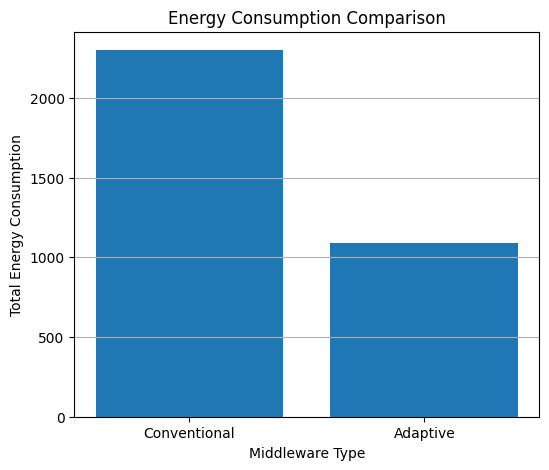

In [ ]:
import matplotlib.pyplot as plt

# Energy comparison values

middleware_types = [
    "Conventional",
    "Adaptive"
]

energy_values = [
    conventional_results["Total Energy"],
    adaptive_results["Total Energy"]
]

# Create graph

plt.figure(figsize=(6,5))

plt.bar(
    middleware_types,
    energy_values
)

plt.xlabel("Middleware Type")

plt.ylabel("Total Energy Consumption")

plt.title(
    "Energy Consumption Comparison"
)

plt.grid(axis='y')
plt.savefig("figure5.png", dpi=300, bbox_inches='tight')

plt.show()

SECTION 12 — COMMUNICATION OVERHEAD GRAPH

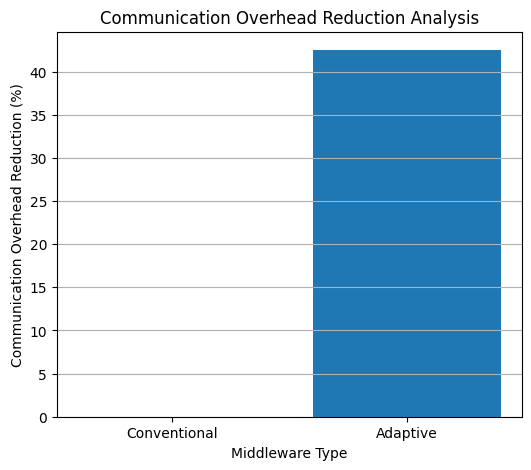

In [ ]:
# Communication overhead values

middleware_types = [
    "Conventional",
    "Adaptive"
]

overhead_values = [
    0,
    adaptive_results[
        "Communication Overhead Reduction (%)"
    ]
]

# Create graph

plt.figure(figsize=(6,5))

plt.bar(
    middleware_types,
    overhead_values
)

plt.xlabel("Middleware Type")

plt.ylabel(
    "Communication Overhead Reduction (%)"
)

plt.title(
    "Communication Overhead Reduction Analysis"
)

plt.grid(axis='y')

plt.show()

SECTION 13 — LATENCY COMPARISON GRAPH

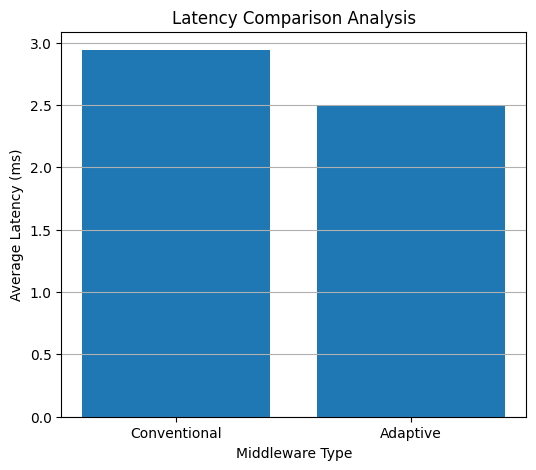

In [ ]:
# Latency comparison values

middleware_types = [
    "Conventional",
    "Adaptive"
]

latency_values = [
    conventional_results["Average Latency"],
    adaptive_results["Average Latency"]
]

# Create graph

plt.figure(figsize=(6,5))

plt.bar(
    middleware_types,
    latency_values
)

plt.xlabel("Middleware Type")

plt.ylabel("Average Latency (ms)")

plt.title("Latency Comparison Analysis")

plt.grid(axis='y')

plt.show()

SECTION 14 — THROUGHPUT COMPARISON GRAPH

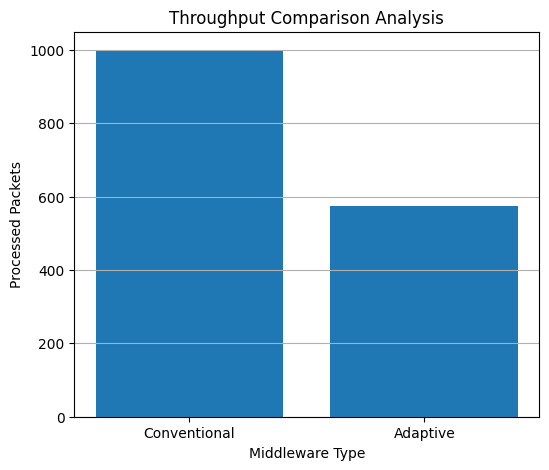

In [ ]:
# Throughput comparison values

middleware_types = [
    "Conventional",
    "Adaptive"
]

throughput_values = [
    conventional_results["Throughput"],
    adaptive_results["Throughput"]
]

# Create graph

plt.figure(figsize=(6,5))

plt.bar(
    middleware_types,
    throughput_values
)

plt.xlabel("Middleware Type")

plt.ylabel("Processed Packets")

plt.title("Throughput Comparison Analysis")

plt.grid(axis='y')

plt.show()

SECTION 15 — MIDDLEWARE EFFICIENCY COMPUTATION

In [ ]:
# Middleware efficiency computation

conventional_efficiency = (
    conventional_results["Throughput"]
    /
    conventional_results["Total Energy"]
)

adaptive_efficiency = (
    adaptive_results["Throughput"]
    /
    adaptive_results["Total Energy"]
)

print("Conventional Efficiency:",
      round(conventional_efficiency, 3))

print("Adaptive Efficiency:",
      round(adaptive_efficiency, 3))

Conventional Efficiency: 0.435
Adaptive Efficiency: 0.528


SECTION 16 — MIDDLEWARE EFFICIENCY GRAPH

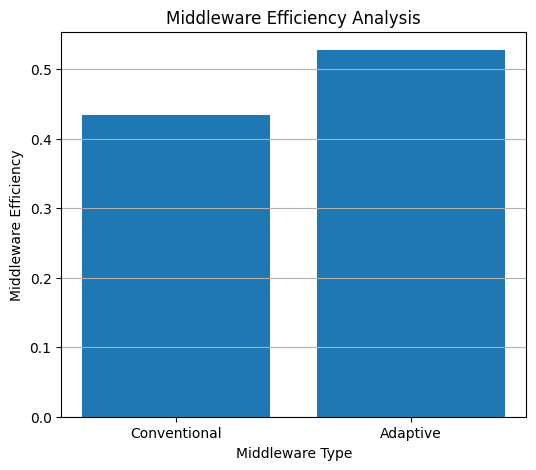

In [ ]:
# Efficiency comparison values

middleware_types = [
    "Conventional",
    "Adaptive"
]

efficiency_values = [
    conventional_efficiency,
    adaptive_efficiency
]

# Create graph

plt.figure(figsize=(6,5))

plt.bar(
    middleware_types,
    efficiency_values
)

plt.xlabel("Middleware Type")

plt.ylabel("Middleware Efficiency")

plt.title(
    "Middleware Efficiency Analysis"
)

plt.grid(axis='y')

plt.show()